In [ ]:
from google.colab import files

uploaded = files.upload()

Saving apple stock.csv to apple stock (1).csv


In [ ]:
!ls -l

total 612
-rw-r--r-- 1 root root 310365 Jun  6 06:00 'apple stock (1).csv'
-rw-r--r-- 1 root root 310365 Jun  6 05:55 'apple stock.csv'
drwxr-xr-x 1 root root   4096 Jun  4 13:32  sample_data


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import io # Import io module for string-based file handling

# 1. Load and Scale
# Get the raw content of the uploaded file.
# Assuming 'uploaded' dictionary is available from the previous `files.upload()` cell.
csv_file_name = 'apple stock (1).csv' # Use the actual uploaded file name

# Ensure the correct file name is used from the 'uploaded' dictionary
if csv_file_name not in uploaded:
    # Fallback to 'apple stock.csv' if 'apple stock (1).csv' is not present
    if 'apple stock.csv' in uploaded:
        csv_file_name = 'apple stock.csv'
    else:
        raise FileNotFoundError(f"'{csv_file_name}' not found in uploaded files. Please ensure the correct file is uploaded.")

csv_data_bytes = uploaded[csv_file_name]
csv_data = csv_data_bytes.decode('utf-8')

# Extract the header line and manually parse column names
# The header line is the first line of the decoded CSV string
header_line = csv_data.splitlines()[0]
header_parts = header_line.split(',')
# Clean up column names: remove empty strings (from leading comma) and strip quotes
actual_column_names = [part.strip('"') for part in header_parts if part.strip('"') != '']

# Now read the CSV data using io.StringIO, skipping the header row (which we parsed manually)
# and assigning the cleaned column names.
df = pd.read_csv(io.StringIO(csv_data), sep=',', quotechar='"', engine='python', header=None, skiprows=1)

# Drop the first column as it's an unnamed index from the CSV data itself
# This aligns the number of DataFrame columns with actual_column_names
df = df.iloc[:, 1:]

df.columns = actual_column_names

print("DataFrame Columns after manual parsing and assignment:", df.columns)

# Ensure the column 'open' exists
if 'open' not in df.columns:
    raise ValueError(f"Column 'open' not found in DataFrame. Available columns: {df.columns.tolist()}")

data = df[['open']].values # Access 'open' column
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# 2. Create Sequences (Sliding Window)
X, y = [], []
for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1)) # LSTM needs 3D input

# 3. Build the Neural Network
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X.shape[1], 1)),
    Dropout(0.2),
    LSTM(50),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X, y, epochs=10, batch_size=32)

DataFrame Columns after manual parsing and assignment: Index(['timestamp', 'open', 'high', 'low', 'close', 'volume'], dtype='object')
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


187/187 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - loss: 0.0034
Epoch 2/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - loss: 0.0012
Epoch 3/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - loss: 8.6782e-04
Epoch 4/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - loss: 8.4627e-04
Epoch 5/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - loss: 7.6883e-04
Epoch 6/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: 7.0944e-04
Epoch 7/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - loss: 6.3311e-04
Epoch 8/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - loss: 5.4388e-04
Epoch 9/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - loss: 5.4374e-04
Epoch 10/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 5.2198e-04


After uploading, you can verify the file is present by listing the files in the current directory.

Once the file is uploaded and you confirm its presence, you can re-run the cell `ExMYg0S0JyuK` to load the data.

187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step


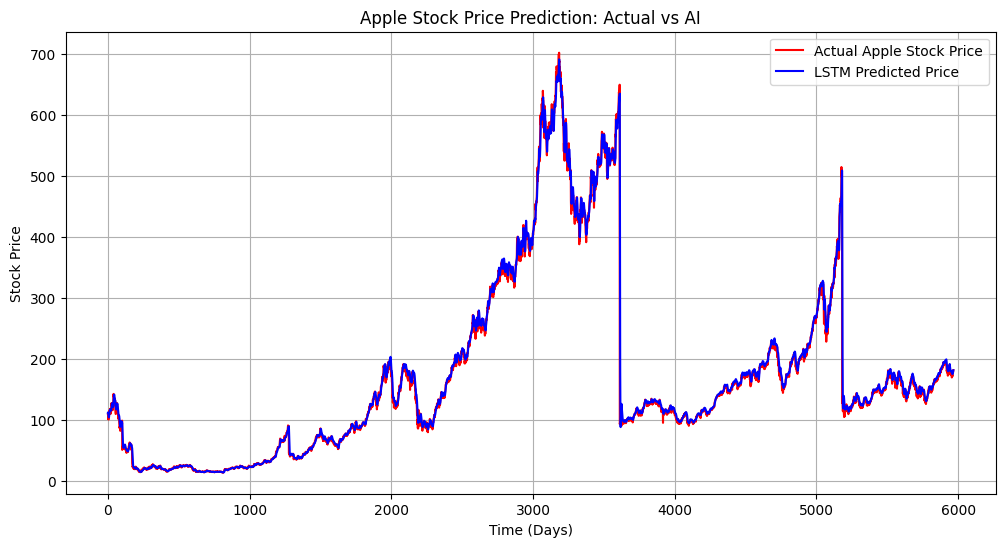

In [ ]:
# 1. Make predictions
predicted_prices = model.predict(X)

# 2. Undo the scaling (Convert 0-1 back to real stock prices)
predicted_prices = scaler.inverse_transform(predicted_prices)
real_prices = scaler.inverse_transform(y.reshape(-1, 1))

# 3. Plot the results
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(real_prices, color='red', label='Actual Apple Stock Price')
plt.plot(predicted_prices, color='blue', label='LSTM Predicted Price')
plt.title('Apple Stock Price Prediction: Actual vs AI')
plt.xlabel('Time (Days)')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import gym
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# 1. Create the environment (A pole balancing on a cart)
env = gym.make("CartPole-v1")

# 2. Build the Q-Network
model = Sequential([
    Dense(24, input_dim=4, activation='relu'),
    Dense(24, activation='relu'),
    Dense(2, activation='linear') # 2 actions: Move Left or Move Right
])
model.compile(loss='mse', optimizer=Adam(learning_rate=0.001))

print("Q-Network is initialized and ready to play!")

Q-Network is initialized and ready to play!


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-pack

In [ ]:
!pip uninstall -y numpy gym
!pip install gymnasium tensorflow

Found existing installation: numpy 2.4.6
Uninstalling numpy-2.4.6:
  Successfully uninstalled numpy-2.4.6
  Using cached numpy-2.4.6-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.4.6-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, which is not installed.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.6 which is incompatible.


In [ ]:
import numpy as np
import gymnasium as gym # Changed from gym to gymnasium
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Random seeds (different from your friend)
np.random.seed(123)
tf.random.set_seed(123)

# Environment
env = gym.make("CartPole-v1")

# Q-Network
model = Sequential([
    Dense(32, input_dim=4, activation='relu'),
    Dense(16, activation='relu'),
    Dense(2, activation='linear')
])
model.compile(loss='mse', optimizer=Adam(learning_rate=0.005))

# Parameters
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.97
epsilon_min = 0.05
scores = []

# Training Loop
for e in range(60):   # more episodes
    res = env.reset()
    state = res[0] if isinstance(res, tuple) else res
    state = np.reshape(state, [1, 4])

    for time in range(300):   # fewer steps per episode
        if np.random.rand() <= epsilon:
            action = env.action_space.sample()
        else:
            q_values = model.predict(state, verbose=0)
            action = np.argmax(q_values[0])

        step_res = env.step(action)
        next_state, reward, done, truncated, info = step_res[0], step_res[1], step_res[2], step_res[3], step_res[4] # Adjusted for gymnasium new step API
        next_state = np.reshape(next_state, [1, 4])

        target = reward
        if not done:
            target = reward + gamma * np.amax(model.predict(next_state, verbose=0)[0])

        target_f = model.predict(state, verbose=0)
        target_f[0][action] = target
        model.fit(state, target_f, epochs=1, verbose=0)

        state = next_state

        if done or truncated: # Check for truncated as well
            scores.append(time)
            print(f"Episode: {e+1}/60, Score: {time}, Epsilon: {epsilon:.2f}")
            break

    if epsilon > epsilon_min:
        epsilon *= epsilon_decay


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Episode: 1/60, Score: 15, Epsilon: 1.00
Episode: 2/60, Score: 42, Epsilon: 0.97
Episode: 3/60, Score: 9, Epsilon: 0.94
Episode: 4/60, Score: 11, Epsilon: 0.91
Episode: 5/60, Score: 47, Epsilon: 0.89
Episode: 6/60, Score: 15, Epsilon: 0.86
Episode: 7/60, Score: 13, Epsilon: 0.83
Episode: 8/60, Score: 12, Epsilon: 0.81
Episode: 9/60, Score: 10, Epsilon: 0.78
Episode: 10/60, Score: 17, Epsilon: 0.76
Episode: 11/60, Score: 15, Epsilon: 0.74
Episode: 12/60, Score: 13, Epsilon: 0.72
Episode: 13/60, Score: 12, Epsilon: 0.69
Episode: 14/60, Score: 11, Epsilon: 0.67
Episode: 15/60, Score: 15, Epsilon: 0.65
Episode: 16/60, Score: 32, Epsilon: 0.63
Episode: 17/60, Score: 20, Epsilon: 0.61
Episode: 18/60, Score: 14, Epsilon: 0.60
Episode: 19/60, Score: 13, Epsilon: 0.58
Episode: 20/60, Score: 14, Epsilon: 0.56
Episode: 21/60, Score: 11, Epsilon: 0.54
Episode: 22/60, Score: 7, Epsilon: 0.53
Episode: 23/60, Score: 24, Epsilon: 0.51
Episode: 24/60, Score: 12, Epsilon: 0.50
Episode: 25/60, Score: 51, 

Variant Q-Network model saved!


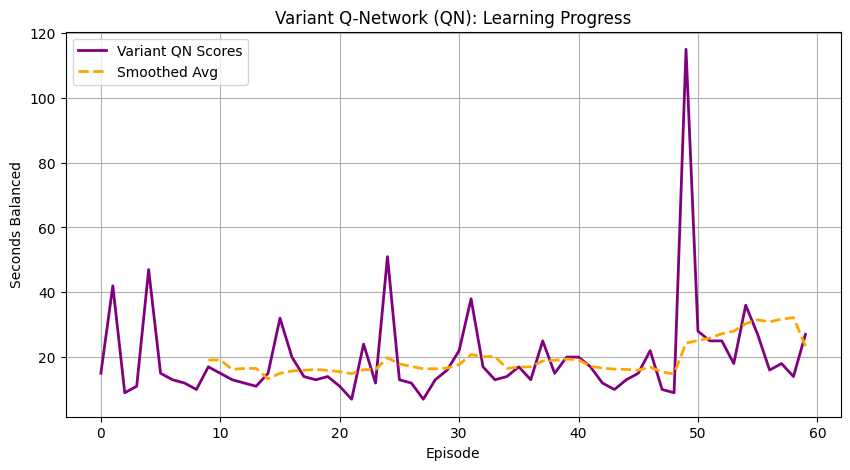

In [ ]:
# 1. Save the Q-Network model (different filename)
model.save('cartpole_qn_variant.h5')
print("Variant Q-Network model saved!")

# 2. Plot the Q-Network Learning Curve
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(10,5))

# Raw scores
plt.plot(scores, color='purple', linewidth=2, label='Variant QN Scores')

# Smoothed curve (moving average over 10 episodes)
smoothed = pd.Series(scores).rolling(10).mean()
plt.plot(smoothed, color='orange', linewidth=2, linestyle='--', label='Smoothed Avg')

plt.title('Variant Q-Network (QN): Learning Progress')
plt.xlabel('Episode')
plt.ylabel('Seconds Balanced')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Test the trained Q-Network (variant version)
total_test_score = 0
num_tests = 10   # changed from 5 to 10

for i in range(num_tests):
    res = env.reset()
    state = res[0] if isinstance(res, tuple) else res
    state = np.reshape(state, [1, 4])
    done = False
    score = 0

    while not done:
        # Always pick the best predicted move (no epsilon)
        q_values = model.predict(state, verbose=0)
        action = np.argmax(q_values[0])

        step_res = env.step(action)
        state, reward, done = step_res[0], step_res[1], step_res[2]
        state = np.reshape(state, [1, 4])
        score += reward

    total_test_score += score
    print(f"Test Game {i+1}: Score = {score}")

avg_score = total_test_score / num_tests
print(f"Average Test Score over {num_tests} games: {avg_score:.2f}")


Test Game 1: Score = 26.0
Test Game 2: Score = 27.0
Test Game 3: Score = 21.0
Test Game 4: Score = 70.0
Test Game 5: Score = 61.0
Test Game 6: Score = 20.0
Test Game 7: Score = 40.0
Test Game 8: Score = 29.0
Test Game 9: Score = 32.0
Test Game 10: Score = 24.0
Average Test Score over 10 games: 35.00
